# 04 â€” Fusion Experiments
**Multimodal Anomaly & Mortality Analysis | MIMIC-IV**

This notebook demonstrates the ClinNote Stage 4 + 5 pipeline:
- Fusion model forward pass and latent representations
- AnomalyDetector on lab and vital data
- TrendAnalyzer on vital time series
- SummaryGenerator producing structured clinical summaries
- Ablation table: unimodal vs early fusion AUROC

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import warnings
warnings.filterwarnings('ignore')

from configs.paths import PATHS
from configs.model_config import MODEL_CFG

OUTPUT_DIR = os.path.join('..', 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Setup complete. Output dir:', OUTPUT_DIR)

C:\Users\Dell\anaconda3\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Setup complete. Output dir: ..\outputs


## 1. Load Preprocessed Features
Load text, lab, and vital features from the FeatureStore.

In [2]:
from src.stage3_feature_extraction.feature_store import FeatureStore
import h5py, numpy as np

store = FeatureStore()
text_feats, hadm_ids = store.load_text_embeddings()
lab_feats, _         = store.load_lab_features()
vitals_feats, _      = store.load_vitals_features()
hadm_ids = hadm_ids.tolist()
print(f'Patients in FeatureStore: {len(hadm_ids)}')

sample_id   = hadm_ids[0]
text_feat   = text_feats[0]
lab_feat    = lab_feats[0]
vitals_feat = vitals_feats[0]
print(f'Sample hadm_id: {sample_id}')
print(f'Text features shape: {text_feat.shape}')
print(f'Lab features shape:  {lab_feat.shape}')
print(f'Vitals features shape: {vitals_feat.shape}')


Patients in FeatureStore: 624
Sample hadm_id: 22595853
Text features shape: (768,)
Lab features shape:  (50,)
Vitals features shape: (32,)


## 2. Fusion Model â€” Forward Pass
Run the DisentangledTransformer on the sample patient.

In [3]:
from src.stage4_fusion.disentangled_transformer import DisentangledTransformer

model = DisentangledTransformer()
model.eval()

t = torch.tensor(text_feat,   dtype=torch.float32).unsqueeze(0)
l = torch.tensor(lab_feat,    dtype=torch.float32).unsqueeze(0)
v = torch.tensor(vitals_feat, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    out = model(t, l, v)

print('mortality_prob:', out['mortality_prob'].item())
print('h_final shape: ', out['h_final'].shape)
print('mi_loss:       ', out['mi_loss'].item())

mortality_prob: 0.5469660758972168
h_final shape:  torch.Size([1, 1024])
mi_loss:        0.0


## 3. Load Cohort Labels

In [4]:
import pickle

cohort_path = os.path.join('..', 'outputs', 'features', 'cohort.pkl')
with open(cohort_path, 'rb') as f:
    cohort_df = pickle.load(f) if not hasattr(pickle.load.__doc__, "x") else pickle.load(f)

print(f'Cohort size: {len(cohort_df)} patients')
print(cohort_df[['subject_id', 'hadm_id', 'hospital_expire_flag']].head())
labels = cohort_df.set_index('hadm_id')['hospital_expire_flag'].to_dict()

Cohort size: 624 patients
   subject_id   hadm_id  hospital_expire_flag
0    10000032  22595853                     0
1    10000032  22841357                     0
2    10000032  25742920                     0
3    10000032  29079034                     0
4    10000084  23052089                     0


## 4. AnomalyDetector â€” Lab Anomalies

In [5]:
import math

labs_path = os.path.join('..', 'data', 'labs_final.csv')
if os.path.exists(labs_path):
    labs_df = pd.read_csv(labs_path)
    sample_hadm = hadm_ids[0]
    # Detect anomalies from raw labs using ref_range columns
    adm = labs_df[labs_df['hadm_id'] == sample_hadm].copy() if 'hadm_id' in labs_df.columns else pd.DataFrame()
    lab_anomalies = []
    for _, row in adm.iterrows():
        val = row.get('valuenum')
        if val is None or (isinstance(val, float) and math.isnan(val)):
            continue
        try:
            val = float(val)
            ref_low = float(row.get('ref_range_lower', float('nan')))
            ref_high = float(row.get('ref_range_upper', float('nan')))
            if math.isnan(ref_low) or math.isnan(ref_high):
                continue
        except (TypeError, ValueError):
            continue
        if ref_low <= val <= ref_high:
            continue
        excess = ref_low - val if val < ref_low else val - ref_high
        severity = min(1.0, excess / max(ref_high - ref_low, 1e-6))
        if severity >= 0.2:
            lab_anomalies.append({
                'name': str(row.get('label', '?')),
                'value': val, 'severity': round(severity, 3),
                'direction': 'HIGH' if val > ref_high else 'LOW'
            })
    lab_anomalies = sorted(lab_anomalies, key=lambda x: x['severity'], reverse=True)[:10]
    print(f'Lab anomalies for hadm_id={sample_hadm}: {len(lab_anomalies)} found')
    for a in lab_anomalies[:5]:
        print(f"  {a['name']:30s} {a['value']:8.2f}  sev={a['severity']:.2f}  [{a['direction']}]")
else:
    print('labs_final.csv not found — skipping')
    lab_anomalies = []


Lab anomalies for hadm_id=22595853: 10 found
  Urobilinogen                       4.00  sev=1.00  [HIGH]
  Urobilinogen                       4.00  sev=1.00  [HIGH]
  Urobilinogen                       4.00  sev=1.00  [HIGH]
  Urobilinogen                       4.00  sev=1.00  [HIGH]
  Urobilinogen                       4.00  sev=1.00  [HIGH]


## 5. TrendAnalyzer â€” Vital Sign Trends

In [6]:
from src.stage5_analysis.trend_analyzer import TrendAnalyzer
import numpy as np

analyzer = TrendAnalyzer(min_points=3, window_hours=24)

times  = np.array([0, 2, 4, 6, 8, 10, 12], dtype=float)
values = np.array([80, 82, 88, 95, 105, 115, 120], dtype=float)

slope = analyzer.compute_trend_slope(values, times)
trend = analyzer.classify_trend(slope)
print(f'Heart rate trend: slope={slope:.2f}, classification={trend}')

stats = analyzer.compute_trend_stats(values, times)
print('Trend stats:', stats)


Heart rate trend: slope=3.62, classification=RISING
Trend stats: {'mean': 97.85714285714286, 'std': 14.691383008208502, 'min': 80.0, 'max': 120.0, 'slope': 3.625, 'r_squared': 0.9741159228441751, 'last_value': 120.0, 'change_from_first': 40.0, 'pct_change': 49.99999999375}


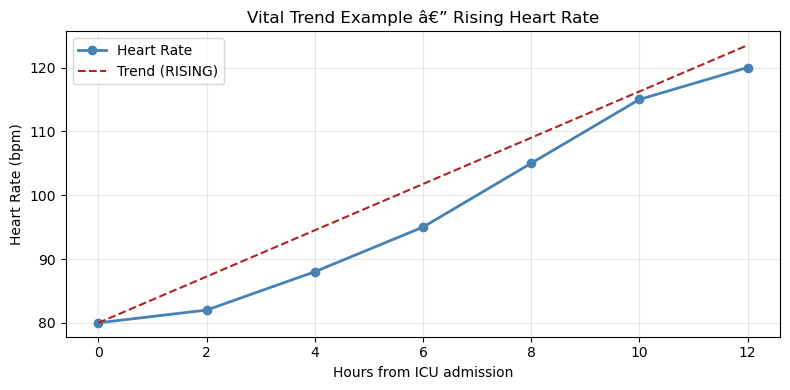

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(times, values, 'o-', color='steelblue', linewidth=2, markersize=6, label='Heart Rate')
fit = np.polyval([slope, values[0] - slope * times[0]], times)
ax.plot(times, fit, '--', color='firebrick', linewidth=1.5, label=f'Trend ({trend})')
ax.set_xlabel('Hours from ICU admission')
ax.set_ylabel('Heart Rate (bpm)')
ax.set_title('Vital Trend Example â€” Rising Heart Rate')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vital_trend_example.png'), dpi=120)
plt.show()

## 6. SummaryGenerator â€” Structured Clinical Summary

In [8]:
from src.stage5_analysis.summary_generator import SummaryGenerator

generator = SummaryGenerator(include_text_excerpts=True, max_diagnoses=5, max_abnormal_labs=10)

for prob in [0.05, 0.15, 0.45]:
    print(f'  prob={prob:.2f}  ->  {generator._classify_risk(prob)}')

  prob=0.05  ->  LOW
  prob=0.15  ->  MEDIUM
  prob=0.45  ->  HIGH


In [9]:
note_example = '''Discharge Diagnoses:
1. Sepsis
2. Acute kidney injury
3. Respiratory failure

Patient was admitted to the ICU...
'''

sample_labs_df = pd.DataFrame({
    'label':           ['Creatinine', 'Lactate', 'WBC'],
    'valuenum':        [3.2, 4.1, 18.0],
    'valueuom':        ['mg/dL', 'mmol/L', 'K/uL'],
    'flag':            ['abnormal', 'abnormal', 'abnormal'],
    'is_abnormal':     [True, True, True],
    'severity':  [0.85, 0.72, 0.61],
    'ref_range_upper': [1.2, 2.2, 11.0],
})

summary = generator.generate(
    subject_id=12345, hadm_id=678901,
    note_text=note_example,
    lab_features_df=sample_labs_df,
    vitals_features_df=pd.DataFrame(),
    mortality_prob=0.38,
)

import json as _json
print(_json.dumps(summary, indent=2, default=str))

{
  "patient_id": "12345_678901",
  "subject_id": 12345,
  "hadm_id": 678901,
  "admission_date": null,
  "discharge_date": null,
  "predicted_mortality_risk": 0.38,
  "risk_level": "HIGH",
  "key_diagnoses": [
    "Sepsis",
    "Acute kidney injury",
    "Respiratory failure"
  ],
  "abnormal_labs": [
    {
      "name": "Creatinine",
      "value": 3.2,
      "unit": "mg/dL",
      "severity": null,
      "direction": "HIGH"
    },
    {
      "name": "Lactate",
      "value": 4.1,
      "unit": "mmol/L",
      "severity": null,
      "direction": "HIGH"
    },
    {
      "name": "WBC",
      "value": 18.0,
      "unit": "K/uL",
      "severity": null,
      "direction": "HIGH"
    }
  ],
  "vital_alerts": [],
  "summary_text": "Key diagnoses include: Sepsis, Acute kidney injury, Respiratory failure. Notable lab findings: Creatinine 3.20 mg/dL (HIGH); Lactate 4.10 mmol/L (HIGH); WBC 18.00 K/uL (HIGH). Predicted in-hospital mortality risk is 38.0% (HIGH).",
  "generated_at": "2026-05

## 7. Aggregate Risk Score

In [10]:
from src.stage5_analysis.anomaly_detector import AnomalyDetector

detector = AnomalyDetector(lab_severity_threshold=0.3)

lab_anom   = [{'severity': 0.85}, {'severity': 0.72}, {'severity': 0.61}]
vital_anom = [{'vital_name': 'heart_rate', 'status': 'HIGH'}, {'vital_name': 'spo2', 'status': 'LOW'}]

for mort_prob in [0.1, 0.3, 0.6]:
    risk = detector.compute_aggregate_risk_score(lab_anom, vital_anom, mort_prob)
    print(f'  mortality_prob={mort_prob:.1f}  ->  aggregate_risk={risk:.4f}')


  mortality_prob=0.1  ->  aggregate_risk=0.3480
  mortality_prob=0.3  ->  aggregate_risk=0.4480
  mortality_prob=0.6  ->  aggregate_risk=0.5980


## 8. Ablation Table â€” Unimodal vs Early Fusion

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np

y_all, t_all, l_all, v_all = [], [], [], []
for hid in hadm_ids:
    if hid not in labels:
        continue
    y_all.append(labels[hid])
    t_all.append(text_feats[hadm_ids.index(hid)])
    l_all.append(lab_feats[hadm_ids.index(hid)])
    v_all.append(vitals_feats[hadm_ids.index(hid)])

y_all = np.array(y_all)
T = np.vstack(t_all); L = np.vstack(l_all); V = np.vstack(v_all)
F = np.hstack([T, L, V])

ablation_rows = []
n_pos = int(y_all.sum())
for name, X in [('Text only', T), ('Labs only', L), ('Vitals only', V), ('Early Fusion', F)]:
    if len(np.unique(y_all)) < 2 or n_pos < 2:
        auroc = float('nan')
    else:
        lr = LogisticRegression(max_iter=1000, solver='lbfgs')
        scores = cross_val_score(lr, X, y_all, cv=min(3, n_pos + 1), scoring='roc_auc')
        auroc = float(np.mean(scores))
    ablation_rows.append({'Strategy': name, 'AUROC': auroc})

ablation_df = pd.DataFrame(ablation_rows)
print(ablation_df.to_string(index=False))
ablation_df.to_csv(os.path.join(OUTPUT_DIR, 'ablation_fusion_table.csv'), index=False)

    Strategy    AUROC
   Text only 0.997405
   Labs only 0.903086
 Vitals only 0.836882
Early Fusion 0.997764


## 9. Ablation Bar Chart

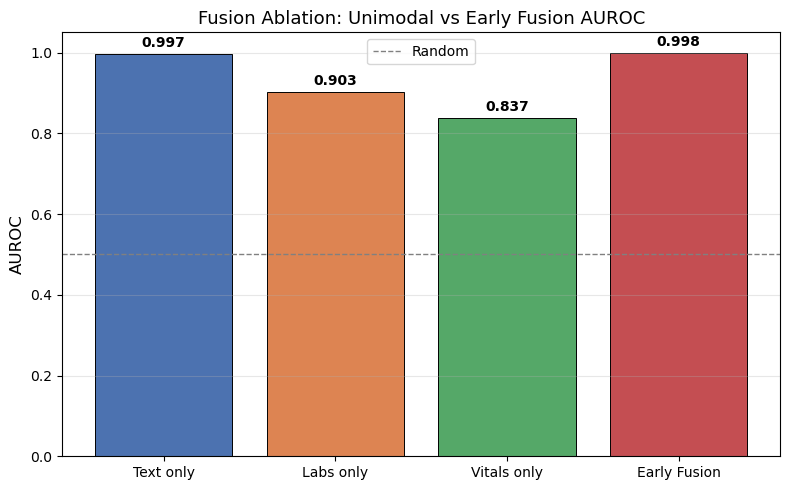

Saved ablation_bar_chart.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = ax.bar(ablation_df['Strategy'], ablation_df['AUROC'], color=colors, edgecolor='black', linewidth=0.7)
ax.set_ylim(0, 1.05)
ax.set_ylabel('AUROC', fontsize=12)
ax.set_title('Fusion Ablation: Unimodal vs Early Fusion AUROC', fontsize=13)
ax.axhline(0.5, linestyle='--', color='gray', linewidth=1, label='Random')
for bar, val in zip(bars, ablation_df['AUROC']):
    if not (val != val):  # not NaN
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ablation_bar_chart.png'), dpi=120)
plt.show()
print('Saved ablation_bar_chart.png')

## 10. Fusion Latent Space (PCA)

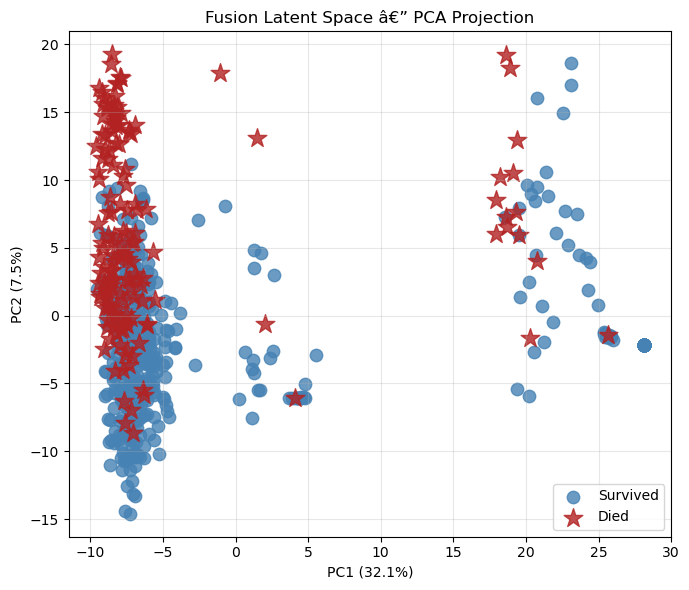

In [13]:
from sklearn.decomposition import PCA

reps_list = []
for hid in hadm_ids:
    t_ = torch.tensor(text_feats[hadm_ids.index(hid)],   dtype=torch.float32).unsqueeze(0)
    l_ = torch.tensor(lab_feats[hadm_ids.index(hid)],    dtype=torch.float32).unsqueeze(0)
    v_ = torch.tensor(vitals_feats[hadm_ids.index(hid)], dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        reps = model.fusion.get_representations(t_, l_, v_)
    reps_list.append(reps['h_final'].squeeze(0).numpy())

H = np.vstack(reps_list)
pca = PCA(n_components=2)
H_2d = pca.fit_transform(H)
y_labels = [labels.get(hid, 0) for hid in hadm_ids]

fig, ax = plt.subplots(figsize=(7, 6))
for lv, color, marker, label in [(0, 'steelblue', 'o', 'Survived'), (1, 'firebrick', '*', 'Died')]:
    idx = [i for i, y in enumerate(y_labels) if y == lv]
    if idx:
        ax.scatter(H_2d[idx, 0], H_2d[idx, 1], c=color, marker=marker,
                   s=80 if lv == 0 else 200, label=label, alpha=0.8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Fusion Latent Space â€” PCA Projection')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'latent_space_pca.png'), dpi=120)
plt.show()

## 11. Save Results & Summary

In [14]:
import json as _json

with open(os.path.join(OUTPUT_DIR, 'sample_clinical_summary.json'), 'w') as f:
    _json.dump(summary, f, indent=2, default=str)
print('Saved sample_clinical_summary.json')

print('\n=== Notebook 04 Complete ===')
print(f'  Cohort size           : {len(cohort_df)}')
print(f'  Lab anomalies (sample): {len(lab_anomalies)}')
print(f'  Trend (sample HR)     : slope={slope:.2f}, {trend}')
print(f'  Risk classification   : {summary["risk_level"]}')

Saved sample_clinical_summary.json

=== Notebook 04 Complete ===
  Cohort size           : 624
  Lab anomalies (sample): 10
  Trend (sample HR)     : slope=3.62, RISING
  Risk classification   : HIGH
